In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.loadtxt("dataset.csv", delimiter=",", skiprows=1)
X = data[: , :3]
y = data[:, 3]

y = y.reshape(-1,1)


In [3]:
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0) # the datapoints are now in a particular range

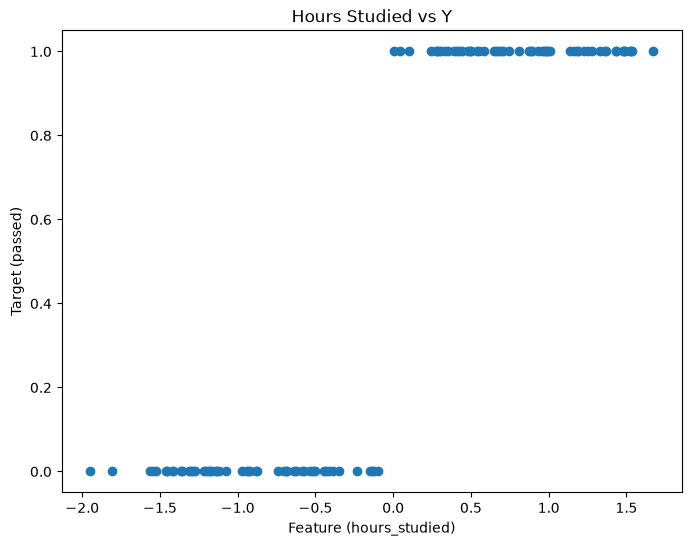

In [4]:
plt.figure(figsize=(8,6))

plt.scatter(X[:, 0], y)

plt.xlabel("Feature (hours_studied)")
plt.ylabel("Target (passed)")
plt.title("Hours Studied vs Y")

plt.show()


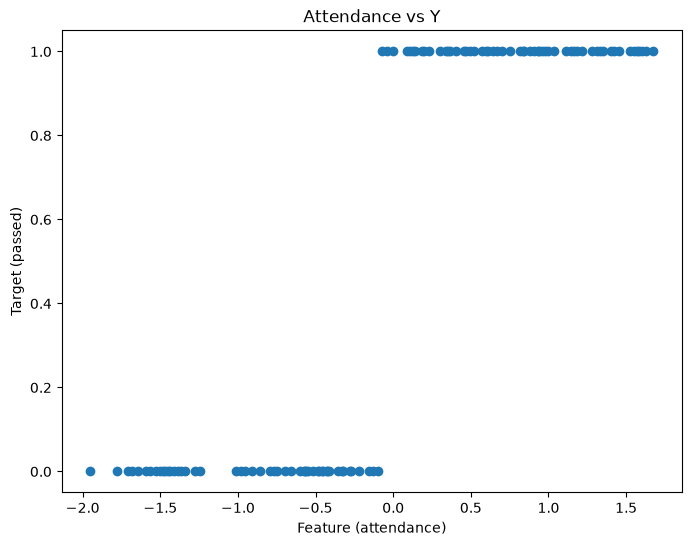

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(X[:, 1], y)

plt.xlabel("Feature (attendance)")
plt.ylabel("Target (passed)")
plt.title("Attendance vs Y")

plt.show()

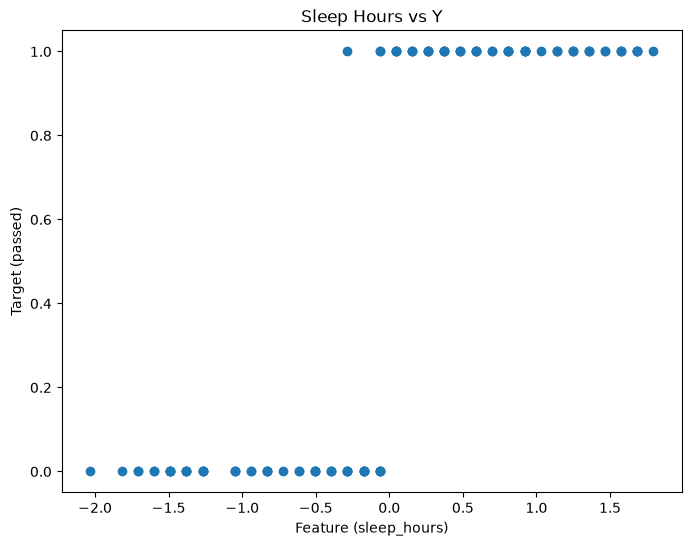

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(X[:, 2], y)

plt.xlabel("Feature (sleep_hours)")
plt.ylabel("Target (passed)")
plt.title("Sleep Hours vs Y")

plt.show()

In [7]:
def hypothesis(w, X, b): 
    z = np.dot(X,w) + b
    return 1/(1 + np.exp(-z))

In [8]:
def loss(y_pred, y, X):
    n = len(y)
    J = -1/n * np.sum(y*np.log(y_pred) + (1-y) * np.log(1-y_pred))

    return J

In [9]:
def gradient(y_pred, y, X):
    n = len(y)
    dw = 1/n * np.dot(X.T,(y_pred - y))
    db = 1/n * np.sum(y_pred - y)

    return dw, db

In [10]:
learning_rate = 0.002
epochs = 3000
w = np.zeros((X.shape[1], 1))
b = 0

for i in range(epochs):
    y_pred = hypothesis(w, X, b)
    
    model_loss = loss(y_pred, y, X)

    dw, db = gradient(y_pred, y, X)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if (i % 100 == 0):
        print(f"Iteration: {i}, Loss: {model_loss}")

Iteration: 0, Loss: 0.6931471805599453
Iteration: 100, Loss: 0.5973860348311324
Iteration: 200, Loss: 0.5257016741323595
Iteration: 300, Loss: 0.4711076618917944
Iteration: 400, Loss: 0.4286295942221493
Iteration: 500, Loss: 0.3948488577391729
Iteration: 600, Loss: 0.3674289468335348
Iteration: 700, Loss: 0.34475766384952494
Iteration: 800, Loss: 0.3257041909043997
Iteration: 900, Loss: 0.3094601529202062
Iteration: 1000, Loss: 0.2954363655016171
Iteration: 1100, Loss: 0.28319528983725206
Iteration: 1200, Loss: 0.2724062436415582
Iteration: 1300, Loss: 0.2628152101963613
Iteration: 1400, Loss: 0.2542241315314013
Iteration: 1500, Loss: 0.24647645910037339
Iteration: 1600, Loss: 0.2394469015002034
Iteration: 1700, Loss: 0.2330340341174248
Iteration: 1800, Loss: 0.22715489194815758
Iteration: 1900, Loss: 0.221740957993578
Iteration: 2000, Loss: 0.21673514818052592
Iteration: 2100, Loss: 0.21208951772186807
Iteration: 2200, Loss: 0.20776349656177936
Iteration: 2300, Loss: 0.203722517568633

## Why the per-feature plots zigzag

Your model uses **3 features** together: `z = w0*x0 + w1*x1 + w2*x2 + b`.

When you plot predicted probability against just *one* feature (sorted), the other two features are **not** sorted along with it -- they jump around randomly at each x-value. That random jumping is what shows up as zigzag in the red curve. It's not a bug in your gradient descent or math, it's a side effect of viewing a multi-feature model through a single-feature slice.

Two ways to get clean curves:

1. **Plot vs. the model's own 1D input `z` (the logit).** Since sigmoid is a pure function of `z`, this is *always* a perfectly smooth S-curve, regardless of how many features you have. Great for sanity-checking the model itself.
2. **Partial dependence per feature** -- hold the *other* features fixed at their mean value, vary just one feature, and predict. This shows "what does increasing hours_studied alone do, all else being average" -- also smooth, and keeps the per-feature interpretation you wanted.

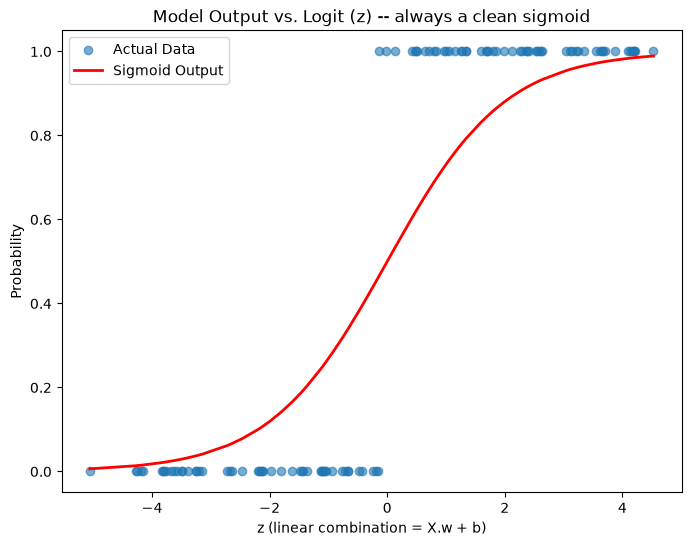

In [11]:
z = np.dot(X, w) + b
y_pred_all = hypothesis(w, X, b)

z_idx = z[:, 0].argsort()
z_sorted = z[z_idx, 0]
pred_sorted = y_pred_all[z_idx, 0]

plt.figure(figsize=(8,6))
plt.scatter(z, y, label="Actual Data", alpha=0.6)
plt.plot(z_sorted, pred_sorted, label="Sigmoid Output", color='red', linewidth=2)

plt.xlabel("z (linear combination = X.w + b)")
plt.ylabel("Probability")
plt.title("Model Output vs. Logit (z) -- always a clean sigmoid")
plt.legend()
plt.show()

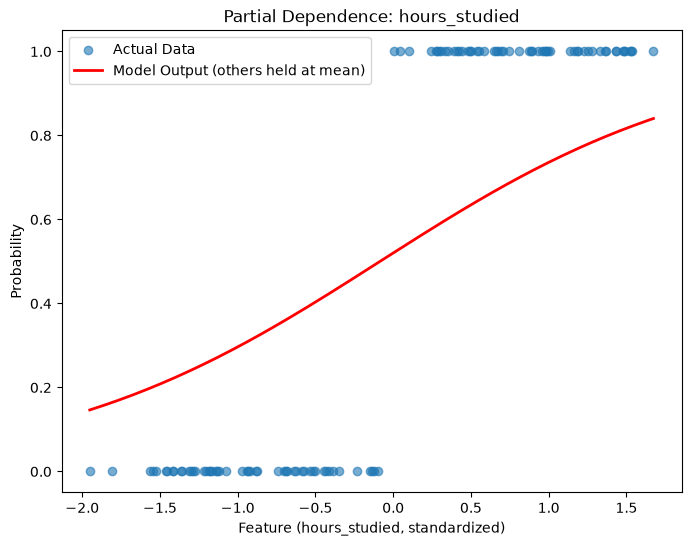

In [12]:
# Partial dependence plot for feature index 0 (hours_studied)
# Hold all other features at their mean, vary only this one
feature_idx = 0

x_range = np.linspace(X[:, feature_idx].min(), X[:, feature_idx].max(), 200)
X_pd = np.tile(np.mean(X, axis=0), (len(x_range), 1))
X_pd[:, feature_idx] = x_range

y_pd = hypothesis(w, X_pd, b)

plt.figure(figsize=(8,6))
plt.scatter(X[:, feature_idx], y, label="Actual Data", alpha=0.6)
plt.plot(x_range, y_pd[:, 0], label="Model Output (others held at mean)", color='red', linewidth=2)

plt.xlabel("Feature (hours_studied, standardized)")
plt.ylabel("Probability")
plt.title("Partial Dependence: hours_studied")
plt.legend()
plt.show()

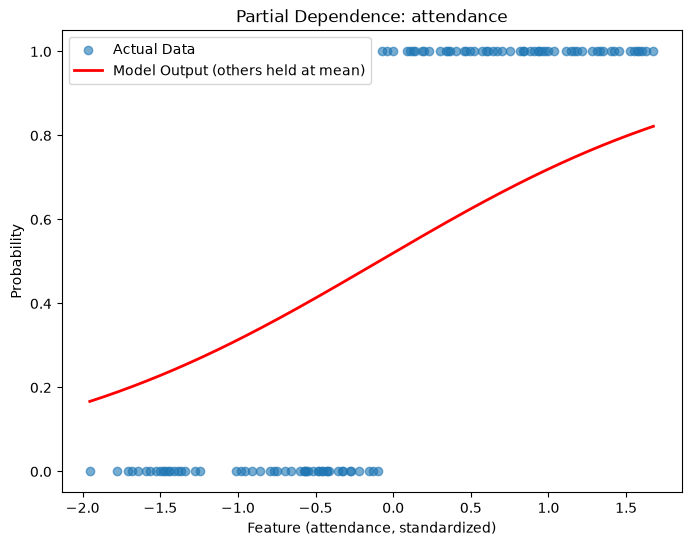

In [13]:
# Partial dependence plot for feature index 1 (attendance)
# Hold all other features at their mean, vary only this one
feature_idx = 1

x_range = np.linspace(X[:, feature_idx].min(), X[:, feature_idx].max(), 200)
X_pd = np.tile(np.mean(X, axis=0), (len(x_range), 1))
X_pd[:, feature_idx] = x_range

y_pd = hypothesis(w, X_pd, b)

plt.figure(figsize=(8,6))
plt.scatter(X[:, feature_idx], y, label="Actual Data", alpha=0.6)
plt.plot(x_range, y_pd[:, 0], label="Model Output (others held at mean)", color='red', linewidth=2)

plt.xlabel("Feature (attendance, standardized)")
plt.ylabel("Probability")
plt.title("Partial Dependence: attendance")
plt.legend()
plt.show()

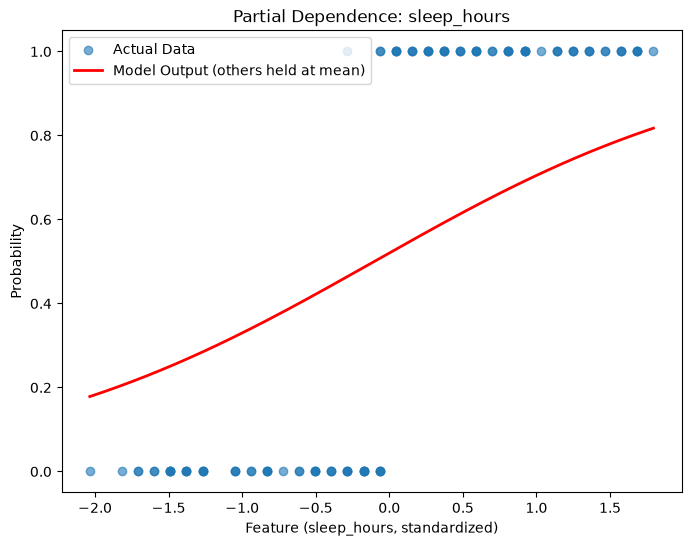

In [14]:
# Partial dependence plot for feature index 2 (sleep_hours)
# Hold all other features at their mean, vary only this one
feature_idx = 2

x_range = np.linspace(X[:, feature_idx].min(), X[:, feature_idx].max(), 200)
X_pd = np.tile(np.mean(X, axis=0), (len(x_range), 1))
X_pd[:, feature_idx] = x_range

y_pd = hypothesis(w, X_pd, b)

plt.figure(figsize=(8,6))
plt.scatter(X[:, feature_idx], y, label="Actual Data", alpha=0.6)
plt.plot(x_range, y_pd[:, 0], label="Model Output (others held at mean)", color='red', linewidth=2)

plt.xlabel("Feature (sleep_hours, standardized)")
plt.ylabel("Probability")
plt.title("Partial Dependence: sleep_hours")
plt.legend()
plt.show()